# 04 — TCOCNN hyperparameter optimization: grid, random, and Bayesian search

All three strategies call the same candidate-training function and minimize validation RMSE. Grid
search is systematic but grows exponentially. Random search explores more combinations per budget.
Bayesian optimization uses previous trials to propose promising settings. Test data never enter a
search objective.

In [1]:
from pathlib import Path
import sys
HERE=Path.cwd()
if not (HERE/'day3_utils.py').exists(): HERE=HERE/'Evaluation Seminar'/'Day_03'
ROOT=HERE.parents[1]
sys.path.insert(0,str(HERE)); sys.path.insert(0,str(ROOT/'Networks'))

import itertools,random,numpy as np
import matplotlib.pyplot as plt
from skopt import Optimizer
from skopt.space import Categorical,Real
from day3_utils import prepare_model_data, train_experiment, plot_comparison
from TCOCNN import TCOCNNClass
splits,scaler=prepare_model_data('acetone'); TRIAL_EPOCHS=60; TRIALS_PER_METHOD=8; SEED=42


In [2]:
trial_predictions={}; trial_histories={}

def evaluate_candidate(params,method,trial):
    # Reset seeds so a configuration is compared under reproducible initialization.
    np.random.seed(SEED); import torch; torch.manual_seed(SEED)
    model,metadata=train_experiment(splits,params,epochs=TRIAL_EPOCHS,seed=SEED)
    prediction=model.predict(splits['val']['X_z']).ravel()
    rmse_z=float(np.sqrt(np.mean((splits['val']['y_z'].ravel()-prediction)**2)))
    row={'method':method,'trial':trial,'validation_RMSE_ppb':rmse_z*scaler['y_std'],**metadata,**params}
    trial_predictions[(method,trial)]=prediction*scaler['y_std']+scaler['y_mean']
    trial_histories[(method,trial)]=model.history.history
    print(method,trial,'RMSE [ppb]=',round(row['validation_RMSE_ppb'],3)); return row

def complete(sample):
    return {'n_filter':sample['n_filter'],'section_depth':3,'kernel':sample['kernel'],'stride':4,
            'num_neurons':sample.get('num_neurons',256),'drop_out':sample['drop_out'],'initial_learning_rate':sample['initial_learning_rate'],
            'batch_size':sample.get('batch_size',64)}


## 1. Grid search

Compare eight configurations across filter width, kernel size, and dense-layer width.
Each candidate gets 60 epochs; all methods use eight trials. Runtime depends on the device.

In [3]:
grid=list(itertools.product([32,64],[7,11],[256,512]))
grid_results=[]
for trial,(filters,kernel,neurons) in enumerate(grid,1):
    grid_results.append(evaluate_candidate(complete({'n_filter':filters,'kernel':kernel,'num_neurons':neurons,'drop_out':.1,'initial_learning_rate':1e-3}), 'grid',trial))


Epoch 1/60: train=297.1094, val=0.9944
Epoch 10/60: train=0.5285, val=0.6769
Epoch 20/60: train=0.5926, val=0.5577
Epoch 30/60: train=0.4533, val=0.4397
Epoch 40/60: train=0.4304, val=0.4056
Epoch 50/60: train=0.3841, val=0.3951
Epoch 60/60: train=0.3632, val=0.4283
grid 1 RMSE [ppb]= 26.512
Epoch 1/60: train=993.2509, val=0.7736
Epoch 10/60: train=0.5860, val=0.7031
Epoch 20/60: train=0.5165, val=0.5574
Epoch 30/60: train=0.4205, val=0.4355
Epoch 40/60: train=0.4459, val=0.4517
Epoch 50/60: train=0.3062, val=0.3731
Epoch 60/60: train=0.3363, val=0.3090
grid 2 RMSE [ppb]= 24.263
Epoch 1/60: train=592.8420, val=0.8486
Epoch 10/60: train=0.5679, val=0.6814
Epoch 20/60: train=0.5836, val=0.4907
Epoch 30/60: train=0.4732, val=0.4507
Epoch 40/60: train=0.3435, val=0.3661
Epoch 50/60: train=0.2913, val=0.4081
Epoch 60/60: train=0.2449, val=0.2813
grid 3 RMSE [ppb]= 23.148
Epoch 1/60: train=772.2042, val=0.9538
Epoch 10/60: train=0.5713, val=1.6278
Epoch 20/60: train=0.5671, val=0.6326
Epoch 

## 2. Random search

Random search samples complete configurations. Log-uniform sampling is appropriate for learning rates
because useful values often span orders of magnitude.

In [4]:
rng=np.random.default_rng(SEED); random_results=[]
for trial in range(1,TRIALS_PER_METHOD+1):
    sample={'n_filter':int(rng.choice([32,48,64])),'kernel':int(rng.choice([5,7,9,11])),
            'drop_out':float(rng.uniform(0,.3)),'initial_learning_rate':float(10**rng.uniform(-4,-2.7))}
    random_results.append(evaluate_candidate(complete(sample),'random',trial))


Epoch 1/60: train=935.0942, val=0.7950
Epoch 10/60: train=0.5674, val=0.8746
Epoch 20/60: train=0.5622, val=0.4538
Epoch 30/60: train=0.5052, val=0.4060
Epoch 40/60: train=0.4142, val=0.4053
Epoch 50/60: train=0.4095, val=0.3843
Epoch 60/60: train=0.3014, val=0.2875
random 1 RMSE [ppb]= 23.403
Epoch 1/60: train=2255.7975, val=0.8127
Epoch 10/60: train=0.5691, val=0.8207
Epoch 20/60: train=0.5956, val=0.4865
Epoch 30/60: train=0.5435, val=0.5747
Epoch 40/60: train=0.3662, val=0.4057
Epoch 50/60: train=0.3520, val=0.4854
Epoch 60/60: train=0.3521, val=0.3864
random 2 RMSE [ppb]= 25.519
Epoch 1/60: train=45.1322, val=0.8069
Epoch 10/60: train=0.6298, val=0.7450
Epoch 20/60: train=0.5853, val=0.6122
Epoch 30/60: train=0.4931, val=0.5057
Epoch 40/60: train=0.4302, val=0.4183
Epoch 50/60: train=0.4137, val=0.3759
Epoch 60/60: train=0.3865, val=0.4490
random 3 RMSE [ppb]= 26.345
Epoch 1/60: train=5256.5857, val=0.7443
Epoch 10/60: train=0.6060, val=4.0509
Epoch 20/60: train=0.5412, val=1.6439

## 3. Bayesian search

The optimizer starts exploratively, then balances uncertain regions against settings predicted to be
good. `ask()` proposes a point and `tell()` returns its observed validation error.

In [ ]:
dimensions=[Categorical([32,48,64],name='n_filter'),Categorical([5,7,9,11],name='kernel'),
            Real(0.,.3,name='drop_out'),Real(1e-4,2e-3,prior='log-uniform',name='initial_learning_rate')]
optimizer=Optimizer(dimensions,random_state=SEED,n_initial_points=3); bayes_results=[]
for trial in range(1,20+1):
    values=optimizer.ask(); sample={dimension.name:value for dimension,value in zip(dimensions,values)}
    row=evaluate_candidate(complete(sample),'bayesian',trial); optimizer.tell(values,row['validation_RMSE_ppb']); bayes_results.append(row)


Epoch 1/60: train=672.1512, val=0.8417
Epoch 10/60: train=0.6245, val=1.3159
Epoch 20/60: train=0.5314, val=0.9625
Epoch 30/60: train=0.5117, val=0.4894
Epoch 40/60: train=0.4882, val=0.3988
Epoch 50/60: train=0.4439, val=0.3895
Epoch 60/60: train=0.4033, val=0.3778
bayesian 1 RMSE [ppb]= 25.89
Epoch 1/60: train=71.4022, val=0.8254
Epoch 10/60: train=0.5167, val=0.7164
Epoch 20/60: train=0.4579, val=0.5194
Epoch 30/60: train=0.4447, val=0.4509
Epoch 40/60: train=0.3122, val=0.3905
Epoch 50/60: train=0.4229, val=0.4389
Epoch 60/60: train=0.4543, val=0.4581
bayesian 2 RMSE [ppb]= 24.711
Epoch 1/60: train=546.3142, val=0.7800
Epoch 10/60: train=0.5021, val=0.9958
Epoch 20/60: train=0.4806, val=0.4604
Epoch 30/60: train=0.4260, val=0.4259
Epoch 40/60: train=0.3033, val=0.3785
Epoch 50/60: train=0.2362, val=0.3954
Epoch 60/60: train=0.2439, val=0.4702
bayesian 3 RMSE [ppb]= 24.434
Epoch 1/60: train=2586.9996, val=0.7858
Epoch 10/60: train=0.7571, val=1.4900
Epoch 20/60: train=0.4684, val=1.

## Compare fairly

Eight trials per method demonstrate the search strategies, not a statistically reliable ranking.
Use validation scatterplots and learning curves to inspect the winning candidates. These search spaces
differ, so this is not a controlled benchmark of optimizers. For stronger conclusions repeat seeds
and grouped validation. Test data remain untouched throughout the search.

Best validation trial: {'method': 'bayesian', 'trial': 4, 'validation_RMSE_ppb': 21.92970218787832, 'best_epoch': 55, 'epochs': 60, 'seed': 42, 'seconds': 9.079847100001643, 'parameters': 8901537, 'n_filter': np.int64(32), 'section_depth': 3, 'kernel': np.int64(9), 'stride': 4, 'num_neurons': 256, 'drop_out': 0.0, 'initial_learning_rate': 0.002, 'batch_size': 64}


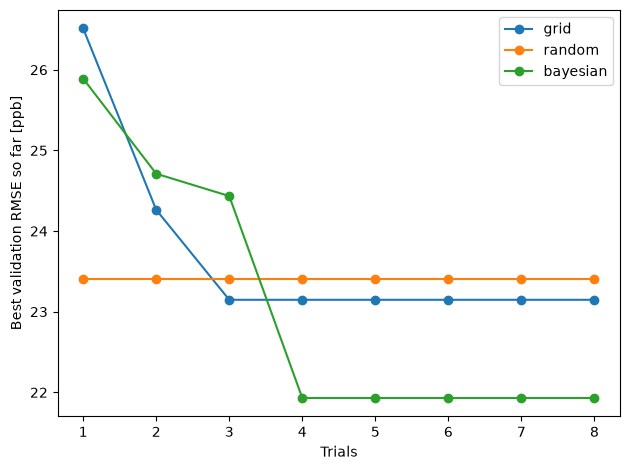

In [6]:
all_results=grid_results+random_results+bayes_results
best=min(all_results,key=lambda row:row['validation_RMSE_ppb'])
print('Best validation trial:',best)
for method in ['grid','random','bayesian']:
    values=[row['validation_RMSE_ppb'] for row in all_results if row['method']==method]
    plt.plot(range(1,len(values)+1),np.minimum.accumulate(values),marker='o',label=method)
plt.xlabel('Trials'); plt.ylabel('Best validation RMSE so far [ppb]'); plt.legend(); plt.tight_layout()


## Inspect each search winner: predictions and residuals

method,trial,validation_RMSE_ppb,best_epoch,epochs,seed,seconds,parameters,n_filter,section_depth,kernel,stride,num_neurons,drop_out,initial_learning_rate,batch_size
bayesian,4,21.930,55,60,42,9.080,8901537,32,3,9,4,256,0.000,0.002,64
bayesian,6,22.312,48,60,42,15.854,8899425,32,3,7,4,256,0.000,0.002,64
bayesian,7,22.391,60,60,42,30.821,13391217,48,3,9,4,256,0.000,0.002,64
grid,3,23.148,60,60,42,9.240,8903649,32,3,11,4,256,0.100,0.001,64
random,1,23.403,60,60,42,9.876,8903649,32,3,11,4,256,0.132,0.001,64
grid,2,24.263,60,60,42,11.874,17747297,32,3,7,4,512,0.100,0.001,64
bayesian,3,24.434,56,60,42,9.795,8901537,32,3,9,4,256,0.017,0.001,64
bayesian,2,24.711,58,60,42,12.608,13381809,48,3,5,4,256,0.138,0.000,64
random,6,25.002,56,60,42,30.041,13381809,48,3,5,4,256,0.166,0.000,64
random,2,25.519,54,60,42,9.311,8901537,32,3,9,4,256,0.028,0.002,64


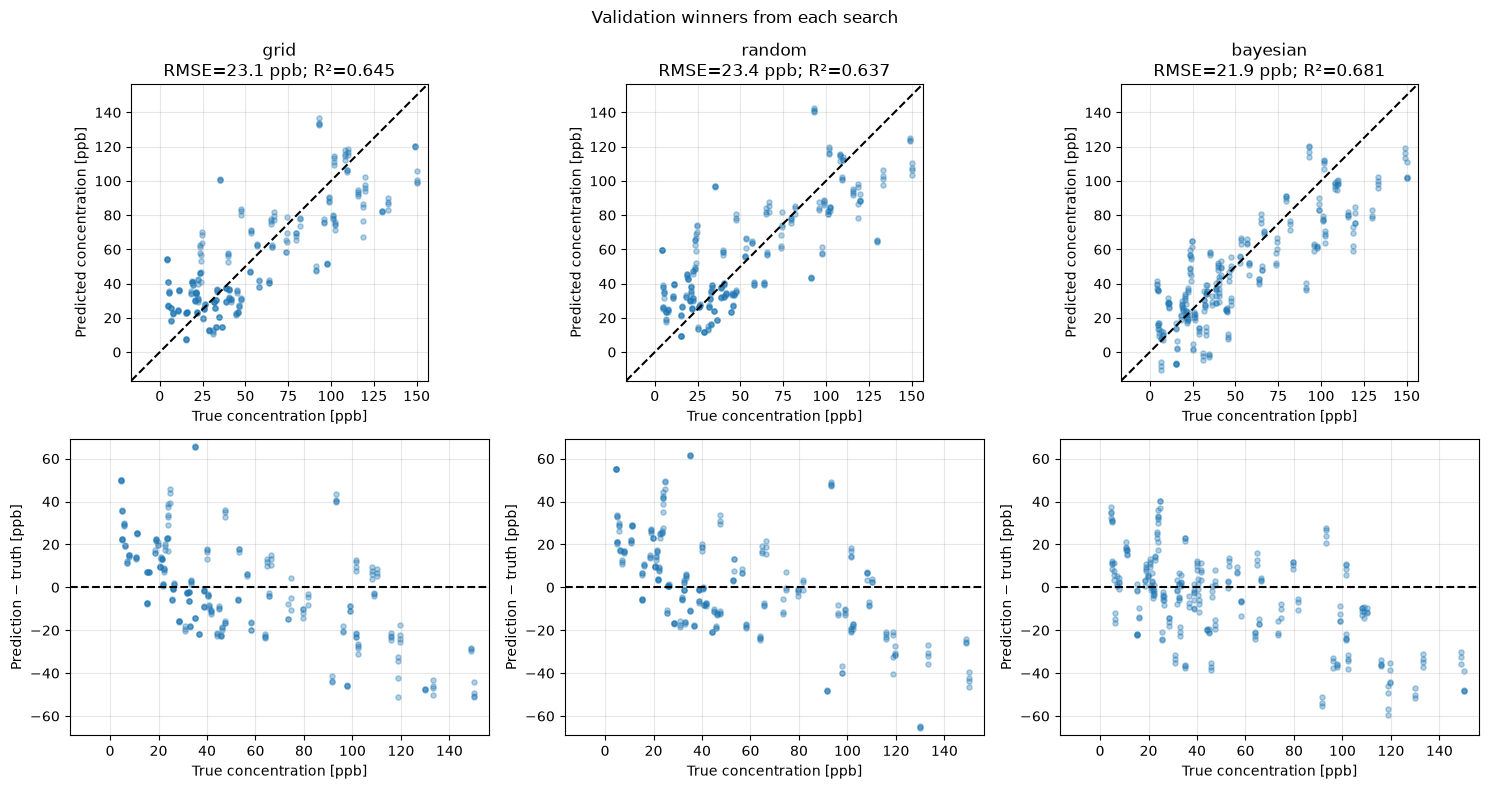

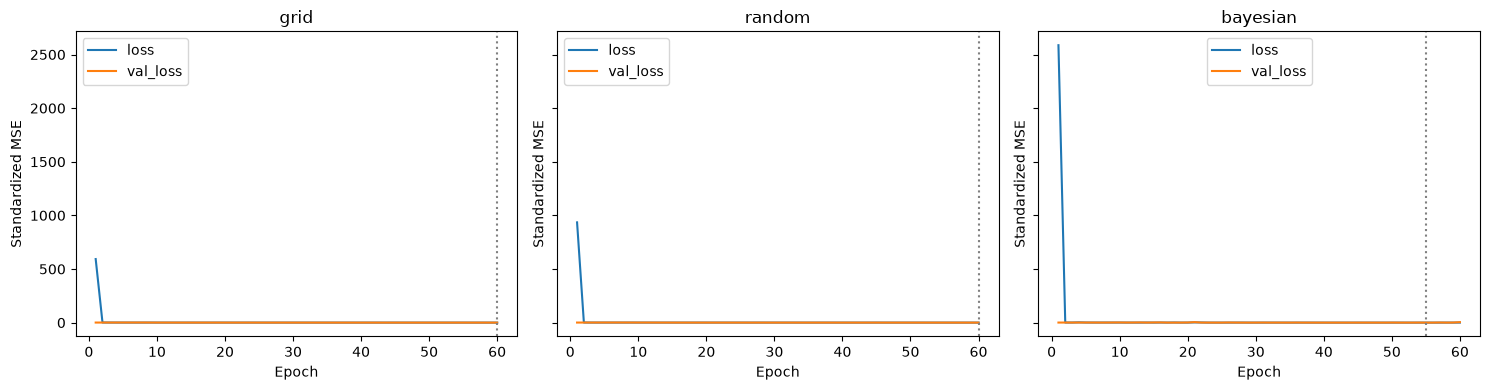

In [7]:
from day3_utils import show_results
show_results(sorted(all_results,key=lambda row:row['validation_RMSE_ppb']))
method_winners={method:min((r for r in all_results if r['method']==method),key=lambda r:r['validation_RMSE_ppb'])
                for method in ['grid','random','bayesian']}
predictions={method:trial_predictions[(method,row['trial'])] for method,row in method_winners.items()}
plot_comparison(splits['val']['y'],predictions,'Validation winners from each search')
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,(method,row) in zip(axes,method_winners.items()):
    history=trial_histories[(method,row['trial'])]
    for key in ['loss','val_loss']: ax.plot(np.arange(1,len(history[key])+1),history[key],label=key)
    ax.axvline(row['best_epoch'],linestyle=':',color='grey')
    ax.set(title=method,xlabel='Epoch',ylabel='Standardized MSE'); ax.legend()
plt.tight_layout(); plt.show()
